# Fase 3 — Preparación de los Datos
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Combina **dos fuentes** y produce un conjunto limpio, balanceado y dividido,
con **estimación de tamaño** por segmentación:

- **Kaggle** (`data/external`): Good→Premium, Bad→Descarte. La carpeta **Mixed se
  EXCLUYE** (varias frutas por foto, fondo no uniforme → se reserva para el
  ejercicio de segmentación).
- **Dataset propio** (`data/raw`): Good→Premium, **Regular→Estándar**, Bad→Descarte.

La clase **Estándar** proviene ahora de imágenes propias *Regular* (1 fruta por
foto), reemplazando al antiguo "Mixed".

Pasos: (1) carga combinada, (2) **cap por fruta×calidad** (corrige sesgo
Pomegranate, EDA §2.3), (3) **split agrupado anti-fuga** 70/15/15, (4) tamaño,
(5) guardado.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

from src.config import (QUALITY_CLASSES, SIZE_CLASSES, CAP_PER_FRUIT_QUALITY,
                        FIGURES_DIR, PROCESSED_DIR)
from src.data import preprocessing as prep
from src.data.segmentation import segment_fruit
from src.data.paths import load_image_rgb
print("Repo:", ROOT)

Repo: /home/juan-pablo/Documents/SEMESTRE7/APO3/PF/fruit-quality-classifier


## 1. Carga combinada (Kaggle sin Mixed + dataset propio)

In [2]:
raw = prep.load_combined_labels()
print("\n[quality × source]")
print(pd.crosstab(raw['quality'], raw['source']).reindex(QUALITY_CLASSES))
print("\n[fruta × calidad]")
print(pd.crosstab(raw['fruit'], raw['quality']).reindex(columns=QUALITY_CLASSES))

[load] Kaggle=18452 | Propio=6859 | Total=25311

[quality × source]
source    kaggle  propio
quality                 
Premium    11664    1201
Estándar       0    4612
Descarte    6788    1046

[fruta × calidad]
quality      Premium  Estándar  Descarte
fruit                                   
Apple           1416       890      1294
Banana          1314       936      1771
Guava           1352       813      1264
Lime            1294       743      1159
Orange          1422       510      1159
Pomegranate     6067       720      1187


## 2. Balanceo por *cap* (fruta × calidad)
El EDA (§2.3) detectó que **Pomegranate_Good** inflaba la clase Premium. Capeando
por *fruta × calidad* evitamos que una sola fruta domine una clase y reducimos el
desbalanceo. El residual lo absorbe `class_weight='balanced'`.

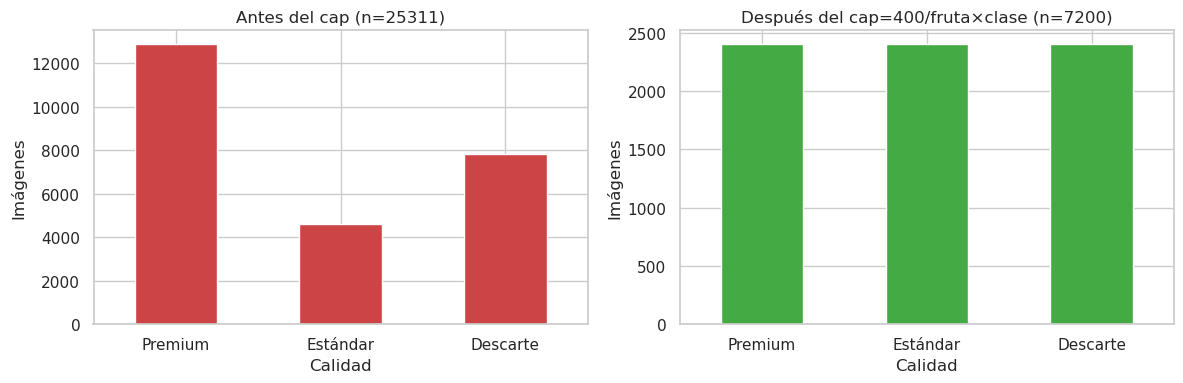

Composición de Premium por fruta (antes vs después):
             antes  después
fruit                      
Pomegranate  0.472    0.167
Orange       0.111    0.167
Apple        0.110    0.167
Guava        0.105    0.167
Banana       0.102    0.167
Lime         0.101    0.167


In [3]:
capped = prep.apply_cap(raw)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
raw['quality'].value_counts().reindex(QUALITY_CLASSES).plot.bar(
    ax=ax[0], color="#c44", title=f"Antes del cap (n={len(raw)})")
capped['quality'].value_counts().reindex(QUALITY_CLASSES).plot.bar(
    ax=ax[1], color="#4a4", title=f"Después del cap={CAP_PER_FRUIT_QUALITY}/fruta×clase (n={len(capped)})")
for a in ax: a.set_xlabel("Calidad"); a.set_ylabel("Imágenes"); a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase3_balanceo.pdf", bbox_inches="tight"); plt.show()
print("Composición de Premium por fruta (antes vs después):")
print(pd.concat([
    raw[raw.quality=='Premium']['fruit'].value_counts(normalize=True).round(3).rename('antes'),
    capped[capped.quality=='Premium']['fruit'].value_counts(normalize=True).round(3).rename('después'),
], axis=1))

## 3. Anti-fuga + split agrupado 70/15/15
El dataset trae **ráfagas de la misma fruta** (Kaggle y propio). Un split aleatorio
filtraría fotos casi idénticas entre train y test → **fuga de datos**. Lo evitamos:
agrupamos casi-duplicados con *perceptual hash* (dHash + Hamming ≤ 5) → `group_id`,
y hacemos el split **por grupo** dentro de cada clase.

In [4]:
from src.data.dedup import assign_groups
capped = capped.copy()
capped['group_id'] = assign_groups(capped['abs_path'].tolist())
print(f"{len(capped)} imágenes -> {capped['group_id'].nunique()} grupos")

split_df = prep.grouped_split(capped)
print(pd.crosstab(split_df['quality'], split_df['split']).reindex(QUALITY_CLASSES)[['train','val','test']])
span = split_df.groupby('group_id')['split'].nunique()
print(f"\nGrupos que cruzan >1 split (debe ser 0): {(span>1).sum()}")

dhash:   0%|          | 0/7200 [00:00<?, ?it/s]

7200 imágenes -> 6124 grupos
split     train  val  test
quality                   
Premium    1680  357   363
Estándar   1695  361   344
Descarte   1682  343   375

Grupos que cruzan >1 split (debe ser 0): 1


## 4. Estimación de tamaño por segmentación (C1)
Diámetro equivalente normalizado por la diagonal, discretizado en terciles
aprendidos **solo en train**. Ejecuta el pipeline completo y guarda los manifests.

In [5]:
df = prep.build_manifests()
thr = df.attrs['size_thresholds']
print(f"\nUmbrales de tamaño: Pequeño < {thr[0]:.3f} ≤ Mediano < {thr[1]:.3f} ≤ Grande")
print("\n[quality × split]")
print(pd.crosstab(df['quality'], df['split']).reindex(QUALITY_CLASSES)[['train','val','test']])

[load] Kaggle=18452 | Propio=6859 | Total=25311


dhash:   0%|          | 0/7200 [00:00<?, ?it/s]

segmentando:   0%|          | 0/7200 [00:00<?, ?it/s]

mixed-seg:   0%|          | 0/1074 [00:00<?, ?it/s]

[mixed] 1513 recortes de enriquecimiento añadidos a train
{'Descarte': 827, 'Estándar': 538, 'Premium': 148}
[build] manifests guardados en /home/juan-pablo/Documents/SEMESTRE7/APO3/PF/fruit-quality-classifier/data/processed (cache de features invalidado)

Umbrales de tamaño: Pequeño < 0.246 ≤ Mediano < 0.377 ≤ Grande

[quality × split]
split     train  val  test
quality                   
Premium    1828  357   363
Estándar   2233  361   344
Descarte   2509  343   375


### 4.1 Distribución de diámetro y clases de tamaño

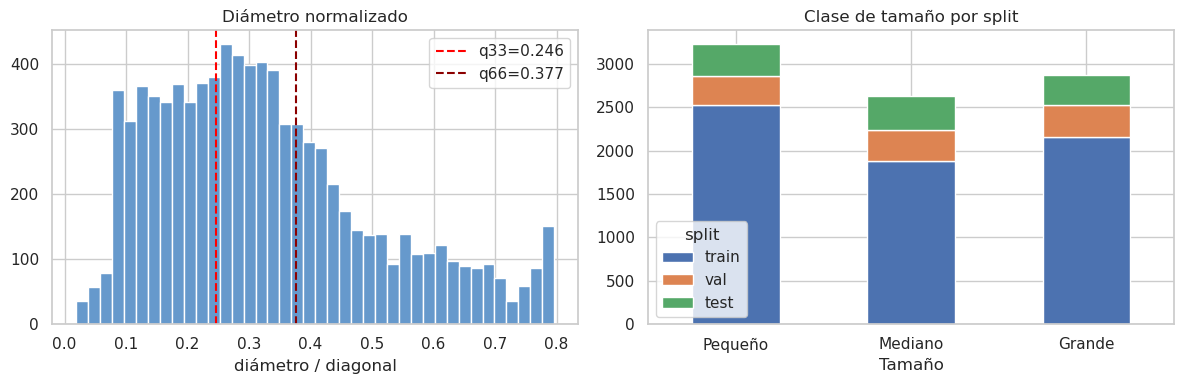

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['diameter_norm'].dropna(), bins=40, color="#69c", edgecolor="white")
ax[0].axvline(thr[0], color="red", ls="--", label=f"q33={thr[0]:.3f}")
ax[0].axvline(thr[1], color="darkred", ls="--", label=f"q66={thr[1]:.3f}")
ax[0].set_title("Diámetro normalizado"); ax[0].set_xlabel("diámetro / diagonal"); ax[0].legend()
pd.crosstab(df['size'], df['split']).reindex(SIZE_CLASSES)[['train','val','test']].plot.bar(ax=ax[1], stacked=True)
ax[1].set_title("Clase de tamaño por split"); ax[1].set_xlabel("Tamaño"); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase3_tamano.pdf", bbox_inches="tight"); plt.show()

### 4.2 Ejemplo visual de segmentación

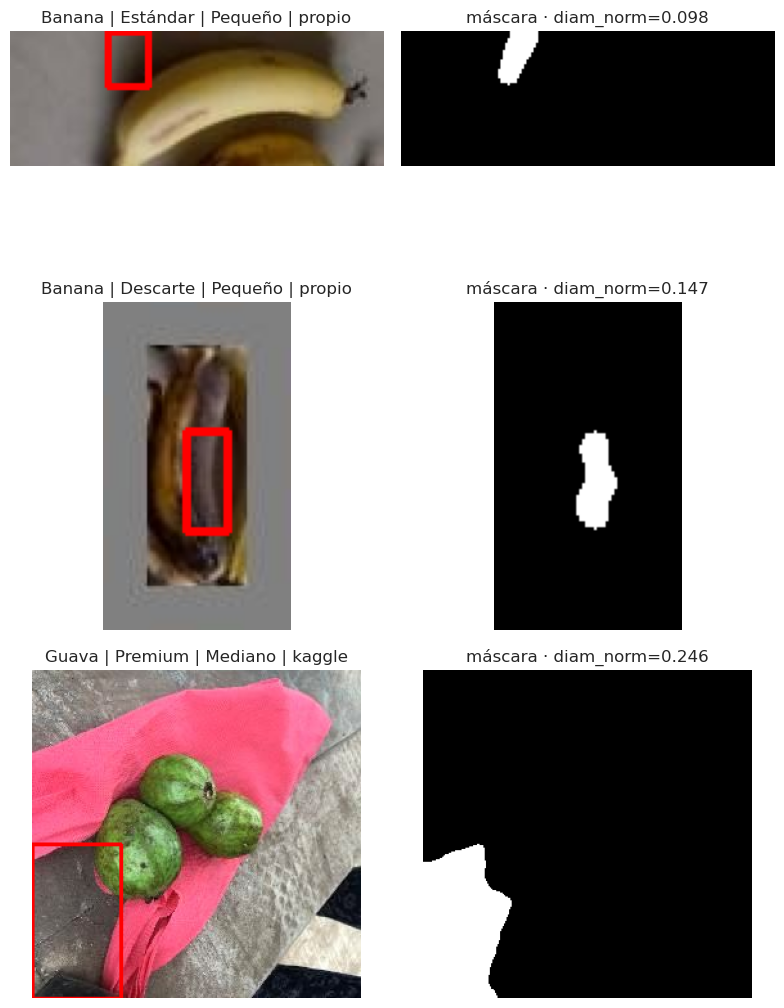

In [7]:
import cv2
samples = df.sample(3, random_state=7)
fig, axes = plt.subplots(3, 2, figsize=(8, 11))
for i, (_, row) in enumerate(samples.iterrows()):
    img = load_image_rgb(row['abs_path']); seg = segment_fruit(img)
    x,y,w,h = seg.bbox; vis = img.copy()
    cv2.rectangle(vis, (x,y), (x+w,y+h), (255,0,0), max(2, img.shape[1]//150))
    axes[i,0].imshow(vis); axes[i,0].set_title(f"{row['fruit']} | {row['quality']} | {row['size']} | {row['source']}")
    axes[i,1].imshow(seg.mask, cmap='gray'); axes[i,1].set_title(f"máscara · diam_norm={seg.diameter_norm:.3f}")
    for a in axes[i]: a.axis('off')
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase3_segmentacion_ejemplos.pdf", bbox_inches="tight"); plt.show()

## 4.3 Enriquecimiento con la carpeta Mixed (segmentación multi-fruta)
La carpeta Kaggle **Mixed** tiene varias frutas por foto. La **segmentamos en
recortes individuales** (cumple el requisito del enunciado) y los re-etiquetamos
por **daño superficial (heurística NTC-4580)**. Estos recortes se añaden **solo a
train** (nunca val/test) → enriquecen el entrenamiento sin meter etiquetas
derivadas de color en la evaluación (evita métricas circulares).

Composición de TRAIN por fuente:
source    kaggle  mixed_seg  propio
quality                            
Premium     1481        148     199
Estándar       0        538    1695
Descarte    1489        827     193


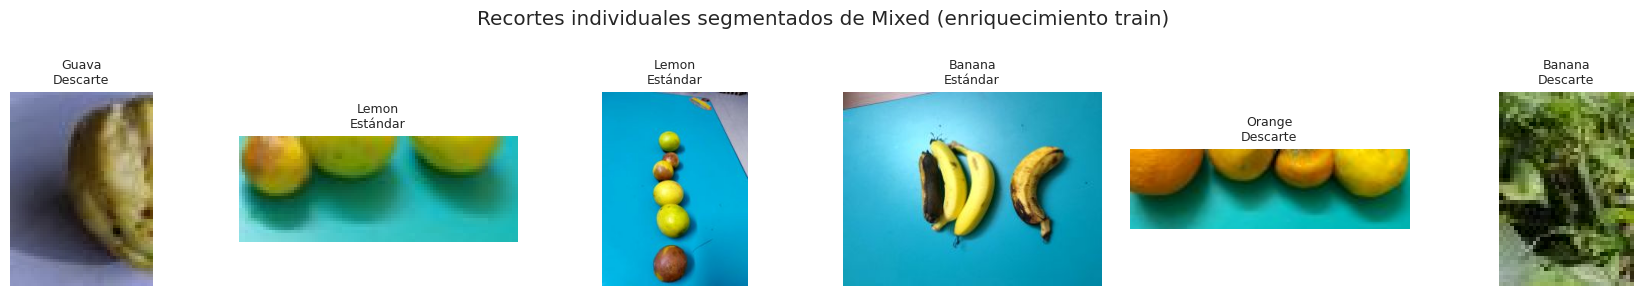

In [8]:
print("Composición de TRAIN por fuente:")
tr = df[df['split']=='train']
print(pd.crosstab(tr['quality'], tr['source']).reindex(QUALITY_CLASSES))
# Ejemplos de recortes segmentados de Mixed
import cv2
seg = df[df['source']=='mixed_seg']
if len(seg):
    s = seg.sample(min(6, len(seg)), random_state=1)
    fig, axes = plt.subplots(1, len(s), figsize=(3*len(s), 3))
    if len(s)==1: axes=[axes]
    for ax,(_,r) in zip(axes, s.iterrows()):
        ax.imshow(load_image_rgb(r['abs_path'])); ax.axis('off')
        ax.set_title(f"{r['fruit']}\n{r['quality']}", fontsize=9)
    plt.suptitle("Recortes individuales segmentados de Mixed (enriquecimiento train)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase3_mixed_segmentado.pdf", bbox_inches="tight"); plt.show()

## 5. Resumen de la Fase 3
- **Dos fuentes combinadas**; Estándar = imágenes propias *Regular* (etiqueta limpia).
- **Cap por fruta×calidad** (corrige sesgo Pomegranate del EDA) + `class_weight`.
- **Split agrupado anti-fuga** (0 grupos cruzando particiones).
- **Mixed segmentado** en frutas individuales y re-etiquetado por daño (NTC-4580),
  añadido **solo a train** como enriquecimiento.
- Tamaño estimado por segmentación (terciles en train).
- Manifests en `data/processed/manifest_{train,val,test}.csv` (columna `source`).

➡️ **Siguiente:** Fase 4 — Modelado.